# Spectral sky recovery

Input vs recovered **flux** and **spectral-index ($\beta$)** maps for the model
$T(\theta,f) = \mathrm{flux}(\theta)\,(f/f_\mathrm{fid})^{\beta(\theta)}$,
fit by variable projection (`lusee.fitting`): flux is the *linear* block (Wiener solve),
$\beta$ the *non-linear* block (outer optimiser).

Run `python notebooks/spectral_fit_demo.py` first.  It writes
`spectral_fit_result_<truth>.npz` (`_ulsa` for real ULSA data, `_powerlaw` for
self-consistent data) — set `RESULT` in the next cell to choose which to view.

In [1]:
%matplotlib inline
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt


In [2]:
# Which fit to view: '_ulsa' (real ULSA data) or '_powerlaw' (self-consistent).
RESULT = 'spectral_fit_result_ulsa.npz'
d = np.load(RESULT)
lmax = int(d['lmax']); Nside = int(d['Nside'])
beta_nside = int(d['beta_nside']); f_fid = float(d['f_fid'])
flux_true = np.asarray(d['flux_true']).astype(complex)
flux_hat  = np.asarray(d['flux_hat']).astype(complex)
beta_true = np.asarray(d['beta_true']); beta_hat = np.asarray(d['beta_hat'])
rho = np.asarray(d['rho'])
print(f'{RESULT}:  lmax={lmax}  Nside={Nside}  beta_nside={beta_nside}  '
      f'freq={np.asarray(d["freq"]).tolist()} MHz  f_fid={f_fid} MHz')

spectral_fit_result_ulsa.npz:  lmax=31  Nside=16  beta_nside=8  freq=[15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0] MHz  f_fid=25.0 MHz


## Flux map: input vs recovered (linear block)

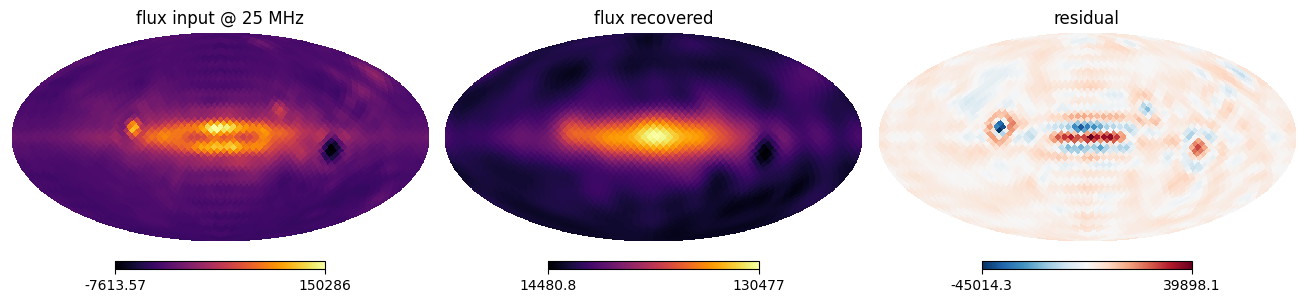

a00: true=134715  rec=134202


In [3]:
true_map = hp.alm2map(flux_true, Nside)
rec_map  = hp.alm2map(flux_hat,  Nside)
plt.figure(figsize=(13, 3.6))
hp.mollview(true_map, sub=(1, 3, 1), title=f'flux input @ {f_fid:.0f} MHz', cmap='inferno')
hp.mollview(rec_map,  sub=(1, 3, 2), title='flux recovered', cmap='inferno')
hp.mollview(rec_map - true_map, sub=(1, 3, 3), title='residual', cmap='RdBu_r')
plt.show()
print(f'a00: true={flux_true[0].real:.0f}  rec={flux_hat[0].real:.0f}')

## Spectral-index map $\beta$: input vs recovered (non-linear block)

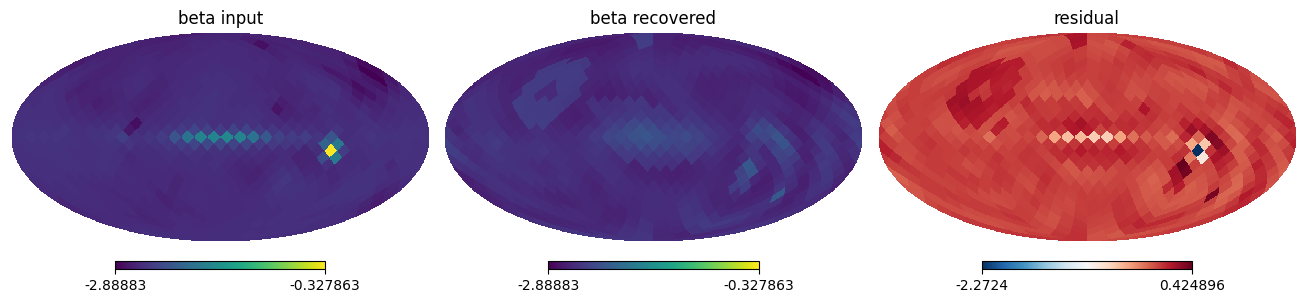

beta RMS(recovered - true) = 0.1237


In [4]:
vmin, vmax = float(beta_true.min()), float(beta_true.max())
plt.figure(figsize=(13, 3.6))
hp.mollview(beta_true, sub=(1, 3, 1), title='beta input', cmap='viridis', min=vmin, max=vmax)
hp.mollview(beta_hat,  sub=(1, 3, 2), title='beta recovered', cmap='viridis', min=vmin, max=vmax)
hp.mollview(beta_hat - beta_true, sub=(1, 3, 3), title='residual', cmap='RdBu_r')
plt.show()
print(f'beta RMS(recovered - true) = {np.sqrt(np.mean((beta_hat - beta_true)**2)):.4f}')

## Flux fidelity: $\rho_\ell$ and angular power spectrum

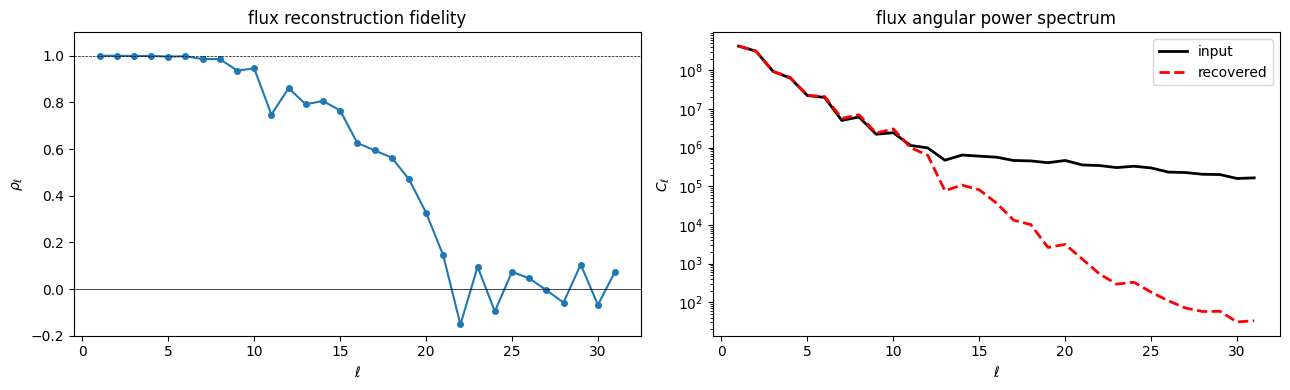

mean rho(1..10) = 0.9843


In [5]:
ell = np.arange(len(rho))
cl_true = hp.alm2cl(flux_true); cl_rec = hp.alm2cl(flux_hat)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(ell[1:lmax + 1], rho[1:lmax + 1], 'o-', ms=4)
a1.axhline(1, ls='--', c='k', lw=0.5); a1.axhline(0, c='k', lw=0.5)
a1.set_xlabel(r'$\ell$'); a1.set_ylabel(r'$\rho_\ell$')
a1.set_ylim(-0.2, 1.1); a1.set_title('flux reconstruction fidelity')
a2.semilogy(ell[1:lmax + 1], cl_true[1:lmax + 1], 'k-', lw=2, label='input')
a2.semilogy(ell[1:lmax + 1], cl_rec[1:lmax + 1], 'r--', lw=2, label='recovered')
a2.set_xlabel(r'$\ell$'); a2.set_ylabel(r'$C_\ell$')
a2.legend(); a2.set_title('flux angular power spectrum')
plt.tight_layout(); plt.show()
print(f'mean rho(1..{min(10, lmax)}) = {np.nanmean(rho[1:min(11, lmax + 1)]):.4f}')

## Optimiser convergence ($\chi^2$ vs evaluation)

Per-evaluation $\chi^2$ (including line-search trials) and the running minimum. At
the realistic SNR the $\chi^2$ floor is set by model mismatch, not noise; the
`converged` flag reports whether L-BFGS-B met its tolerance before `maxiter`.

In [ ]:
if 'chi2_history' not in d.files:
    print('No chi2_history in this npz -- re-run the fit (driver now saves it).')
else:
    hist = np.asarray(d['chi2_history'])
    ev = np.arange(1, len(hist) + 1)
    runmin = np.minimum.accumulate(hist)
    conv = bool(d['converged']) if 'converged' in d.files else None
    plt.figure(figsize=(7, 4))
    plt.semilogy(ev, hist, '.', ms=3, alpha=0.4, label='per evaluation')
    plt.semilogy(ev, runmin, '-', lw=2, label='running minimum')
    plt.xlabel('function evaluation'); plt.ylabel(r'$\chi^2$')
    plt.title(f'optimiser convergence (converged={conv})')
    plt.legend(); plt.tight_layout(); plt.show()
    print(f'final chi2 = {hist[-1]:.4e}  over {len(hist)} evals  (converged={conv})')